# Early Product Success Prediction: Logistic Regression vs XGBoost

This notebook evaluates whether product success can be predicted using only the first 4 weeks of post-launch review
data.

We define product success as being in the top 10% of products within each category based on lifetime review count. We
construct product-level early features from the first 4 weeks of reviews, then compare a baseline Logistic Regression
model against an XGBoost classifier using the same train/test split.

In [3]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
# ==========================================
# Cell 2 — Imports and config
# ==========================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SAMPLES_DIR = Path("samples")
FOUR_WEEKS_DAYS = 28
TOP_PCT = 0.10
TEST_SIZE = 0.20
RANDOM_SEED = 42
SUCCESS_LABEL_NAME = "success_top10"

In [5]:
# ==========================================
# Cell 3 — Helper functions
# ==========================================
def safe_numeric_vote(series: pd.Series) -> pd.Series:
    """
    Convert strings like '1,234' to numeric vote counts.
    Missing values become 0.
    """
    return (
        series.fillna("0")
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace({"": "0", "nan": "0", "None": "0"})
        .pipe(pd.to_numeric, errors="coerce")
        .fillna(0)
    )


def precision_at_k(y_true, y_score, k: int) -> float:
    """
    Precision among the top-k highest-scoring predictions.
    """
    if k <= 0:
        return np.nan
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    order = np.argsort(-y_score)
    top_k = y_true[order][:k]
    return float(np.mean(top_k))


def build_product_features_from_reviews(df_reviews: pd.DataFrame, category_name: str) -> pd.DataFrame:
    """
    Build product-level features using only the first 4 weeks of reviews
    after the first observed review for each product.
    """
    df = df_reviews.copy()

    # Numeric conversions
    df["unixReviewTime"] = pd.to_numeric(df["unixReviewTime"], errors="coerce")
    df["overall"] = pd.to_numeric(df["overall"], errors="coerce")

    if "vote" in df.columns:
        df["vote_num"] = safe_numeric_vote(df["vote"])
    else:
        df["vote_num"] = 0.0

    if "verified" in df.columns:
        df["verified_num"] = df["verified"].fillna(False).astype(int)
    else:
        df["verified_num"] = 0

    if "reviewText" in df.columns:
        df["review_text_len"] = df["reviewText"].fillna("").astype(str).str.len()
    else:
        df["review_text_len"] = 0

    if "summary" in df.columns:
        df["summary_len"] = df["summary"].fillna("").astype(str).str.len()
    else:
        df["summary_len"] = 0

    # Drop rows missing key identifiers or timestamps
    df = df.dropna(subset=["asin", "unixReviewTime", "overall"]).copy()

    # Sort within product
    df = df.sort_values(["asin", "unixReviewTime"]).reset_index(drop=True)

    # Relative time from first observed review
    first_time = df.groupby("asin")["unixReviewTime"].transform("min")
    df["days_since_first"] = (df["unixReviewTime"] - first_time) / (24 * 60 * 60)

    # Restrict to first 4 weeks
    df_4w = df[df["days_since_first"] <= FOUR_WEEKS_DAYS].copy()

    # Review sequence number within first 4 weeks
    df_4w["review_order"] = df_4w.groupby("asin").cumcount() + 1

    grp = df_4w.groupby("asin", sort=False)

    # Aggregate features
    features = grp.agg(
        n_reviews_4w=("overall", "size"),
        mean_rating_4w=("overall", "mean"),
        std_rating_4w=("overall", "std"),
        min_rating_4w=("overall", "min"),
        max_rating_4w=("overall", "max"),
        median_rating_4w=("overall", "median"),
        verified_ratio_4w=("verified_num", "mean"),
        mean_vote_4w=("vote_num", "mean"),
        sum_vote_4w=("vote_num", "sum"),
        mean_review_text_len_4w=("review_text_len", "mean"),
        mean_summary_len_4w=("summary_len", "mean"),
        first_4w_day_span=("days_since_first", "max"),
    ).reset_index()

    def rating_slope(sub: pd.DataFrame) -> float:
        x = sub["days_since_first"].to_numpy(dtype=float)
        y = sub["overall"].to_numpy(dtype=float)
        if len(x) < 2 or np.allclose(x, x[0]):
            return 0.0
        return float(np.polyfit(x, y, 1)[0])

    def review_velocity_slope(sub: pd.DataFrame) -> float:
        x = sub["days_since_first"].to_numpy(dtype=float)
        y = sub["review_order"].to_numpy(dtype=float)
        if len(x) < 2 or np.allclose(x, x[0]):
            return 0.0
        return float(np.polyfit(x, y, 1)[0])

    def late_minus_early_rating(sub: pd.DataFrame) -> float:
        sub = sub.sort_values("days_since_first")
        midpoint = FOUR_WEEKS_DAYS / 2

        early = sub.loc[sub["days_since_first"] <= midpoint, "overall"]
        late = sub.loc[sub["days_since_first"] > midpoint, "overall"]

        if len(early) == 0 or len(late) == 0:
            return 0.0

        return float(late.mean() - early.mean())

    slopes = grp.apply(
        lambda sub: pd.Series({
            "rating_slope_4w": rating_slope(sub),
            "review_velocity_slope_4w": review_velocity_slope(sub),
            "late_minus_early_rating_4w": late_minus_early_rating(sub),
        })
    ).reset_index()

    features = features.merge(slopes, on="asin", how="left")

    # Derived features
    features["reviews_per_day_4w"] = features["n_reviews_4w"] / FOUR_WEEKS_DAYS
    features["vote_per_review_4w"] = features["sum_vote_4w"] / features["n_reviews_4w"].clip(lower=1)
    features["category"] = category_name

    fill_zero_cols = [
        "std_rating_4w",
        "rating_slope_4w",
        "review_velocity_slope_4w",
        "late_minus_early_rating_4w",
    ]
    for col in fill_zero_cols:
        features[col] = features[col].fillna(0.0)

    return features


def build_success_labels(df_reviews: pd.DataFrame, top_pct: float = 0.10) -> pd.DataFrame:
    """
    Label the top X% of products within a category as successful,
    based on lifetime review count.
    """
    df = df_reviews.copy()
    df["overall"] = pd.to_numeric(df["overall"], errors="coerce")
    df["unixReviewTime"] = pd.to_numeric(df["unixReviewTime"], errors="coerce")
    df = df.dropna(subset=["asin", "unixReviewTime", "overall"]).copy()

    lifetime = (
        df.groupby("asin")
        .agg(
            total_reviews_lifetime=("overall", "size"),
            lifetime_mean_rating=("overall", "mean"),
            first_review_time=("unixReviewTime", "min"),
            last_review_time=("unixReviewTime", "max"),
        )
        .reset_index()
        .sort_values("total_reviews_lifetime", ascending=False)
        .reset_index(drop=True)
    )

    n_products = len(lifetime)
    n_top = max(1, int(np.ceil(top_pct * n_products)))

    lifetime[SUCCESS_LABEL_NAME] = 0
    lifetime.loc[:n_top - 1, SUCCESS_LABEL_NAME] = 1

    return lifetime


def evaluate_model(y_true, y_proba, threshold: float = 0.5) -> dict:
    """
    Compute a standard set of binary classification metrics.
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    y_pred = (y_proba >= threshold).astype(int)

    k = int(np.sum(y_true))

    return {
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Average Precision": average_precision_score(y_true, y_proba),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision@K": precision_at_k(y_true, y_proba, k),
        "Test Positive Rate": float(np.mean(y_true)),
        "K used for Precision@K": int(k),
    }


def metrics_dict_to_df(metrics_dict: dict, model_name: str) -> pd.DataFrame:
    """
    Convert metrics dict to a display-friendly dataframe.
    """
    return pd.DataFrame({
        "metric": list(metrics_dict.keys()),
        model_name: list(metrics_dict.values())
    })


def compute_category_metrics(test_df: pd.DataFrame, category_col: str = "category") -> pd.DataFrame:
    """
    Compute evaluation metrics by category.
    Expects columns: category, y_true, y_proba, y_pred
    """
    rows = []

    for category, sub in test_df.groupby(category_col):
        if sub["y_true"].nunique() < 2:
            continue

        rows.append({
            "category": category,
            "n_products": len(sub),
            "positive_rate": sub["y_true"].mean(),
            "roc_auc": roc_auc_score(sub["y_true"], sub["y_proba"]),
            "avg_precision": average_precision_score(sub["y_true"], sub["y_proba"]),
            "precision": precision_score(sub["y_true"], sub["y_pred"], zero_division=0),
            "recall": recall_score(sub["y_true"], sub["y_pred"], zero_division=0),
            "f1": f1_score(sub["y_true"], sub["y_pred"], zero_division=0),
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)

In [6]:
# ==========================================
# Cell 4 — Build the product-level dataset
# ==========================================
all_product_rows = []

category_dirs = sorted([d for d in SAMPLES_DIR.iterdir() if d.is_dir()])

print(f"Found {len(category_dirs)} category folders")

for category_dir in category_dirs:
    file_path = category_dir / "sample_reviews.parquet"
    category_name = category_dir.name

    if not file_path.exists():
        print(f"Skipping {category_name}: sample_reviews.parquet not found")
        continue

    print(f"Loading category: {category_name}")

    needed_cols = [
        "asin",
        "overall",
        "unixReviewTime",
        "reviewText",
        "summary",
        "verified",
        "vote",
    ]

    df_reviews = pd.read_parquet(file_path, columns=needed_cols)

    features = build_product_features_from_reviews(df_reviews, category_name=category_name)
    labels = build_success_labels(df_reviews, top_pct=TOP_PCT)

    category_product_df = features.merge(labels, on="asin", how="inner")
    all_product_rows.append(category_product_df)

product_df = pd.concat(all_product_rows, ignore_index=True)

print("Final product-level dataset shape:", product_df.shape)
product_df.head()

Found 5 category folders
Loading category: Clothing, Shoes and Jewelry
Loading category: Electronics
Loading category: Sports_and_Outdoors
Loading category: Tools and Home Improvement
Loading category: Toys_and_Games
Final product-level dataset shape: (50000, 24)


,asin,n_reviews_4w,mean_rating_4w,std_rating_4w,min_rating_4w,max_rating_4w,median_rating_4w,verified_ratio_4w,mean_vote_4w,sum_vote_4w,...,review_velocity_slope_4w,late_minus_early_rating_4w,reviews_per_day_4w,vote_per_review_4w,category,total_reviews_lifetime,lifetime_mean_rating,first_review_time,last_review_time,success_top10
0,5120053351,6,5.0,0.00000,5.0,5.0,5.0,0.50,11.166667,67,...,0.154286,0.000000,0.214286,11.166667,"Clothing, Shoes and Jewelry",52,4.000000,1453507200,1520294400,0
1,5120053890,4,4.5,0.57735,4.0,5.0,4.5,0.25,1.500000,6,...,0.140397,-0.666667,0.142857,1.500000,"Clothing, Shoes and Jewelry",34,4.588235,1465516800,1522713600,0
2,B00001W0GC,1,5.0,0.00000,5.0,5.0,5.0,1.00,0.000000,0,...,0.000000,0.000000,0.035714,0.000000,"Clothing, Shoes and Jewelry",68,3.588235,1257897600,1513728000,0
3,B000074RL3,1,5.0,0.00000,5.0,5.0,5.0,0.00,28.000000,28,...,0.000000,0.000000,0.035714,28.000000,"Clothing, Shoes and Jewelry",29,4.517241,1112313600,1523664000,0
4,B0000865II,1,4.0,0.00000,4.0,4.0,4.0,1.00,0.000000,0,...,0.000000,0.000000,0.035714,0.000000,"Clothing, Shoes and Jewelry",396,4.063131,1168819200,1526515200,1


In [7]:
# ==========================================
# Cell 5 — Sanity checks
# ==========================================
print("Overall shape:", product_df.shape)
print("\nColumns:")
print(product_df.columns.tolist())

print("\nMissing values (top 20):")
display(product_df.isna().sum().sort_values(ascending=False).head(20))

label_summary = (
    product_df.groupby("category")[SUCCESS_LABEL_NAME]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "n_products", "sum": "n_success", "mean": "success_rate"})
    .reset_index()
)

print("\nSuccess rate by category:")
display(label_summary)

print("\nPreview:")
display(product_df.head())

print("\nSelected numeric summary:")
display(
    product_df[
        [
            "n_reviews_4w",
            "mean_rating_4w",
            "std_rating_4w",
            "reviews_per_day_4w",
            "rating_slope_4w",
            "review_velocity_slope_4w",
            "total_reviews_lifetime",
        ]
    ].describe()
)

Overall shape: (50000, 24)

Columns:
['asin', 'n_reviews_4w', 'mean_rating_4w', 'std_rating_4w', 'min_rating_4w', 'max_rating_4w', 'median_rating_4w', 'verified_ratio_4w', 'mean_vote_4w', 'sum_vote_4w', 'mean_review_text_len_4w', 'mean_summary_len_4w', 'first_4w_day_span', 'rating_slope_4w', 'review_velocity_slope_4w', 'late_minus_early_rating_4w', 'reviews_per_day_4w', 'vote_per_review_4w', 'category', 'total_reviews_lifetime', 'lifetime_mean_rating', 'first_review_time', 'last_review_time', 'success_top10']

Missing values (top 20):


asin                          0
n_reviews_4w                  0
last_review_time              0
first_review_time             0
lifetime_mean_rating          0
total_reviews_lifetime        0
category                      0
vote_per_review_4w            0
reviews_per_day_4w            0
late_minus_early_rating_4w    0
review_velocity_slope_4w      0
rating_slope_4w               0
first_4w_day_span             0
mean_summary_len_4w           0
mean_review_text_len_4w       0
sum_vote_4w                   0
mean_vote_4w                  0
verified_ratio_4w             0
median_rating_4w              0
max_rating_4w                 0
dtype: int64


Success rate by category:


,category,n_products,n_success,success_rate
0,"Clothing, Shoes and Jewelry",10000,1000,0.1
1,Electronics,10000,1000,0.1
2,Sports_and_Outdoors,10000,1000,0.1
3,Tools and Home Improvement,10000,1000,0.1
4,Toys_and_Games,10000,1000,0.1



Preview:


,asin,n_reviews_4w,mean_rating_4w,std_rating_4w,min_rating_4w,max_rating_4w,median_rating_4w,verified_ratio_4w,mean_vote_4w,sum_vote_4w,...,review_velocity_slope_4w,late_minus_early_rating_4w,reviews_per_day_4w,vote_per_review_4w,category,total_reviews_lifetime,lifetime_mean_rating,first_review_time,last_review_time,success_top10
0,5120053351,6,5.0,0.00000,5.0,5.0,5.0,0.50,11.166667,67,...,0.154286,0.000000,0.214286,11.166667,"Clothing, Shoes and Jewelry",52,4.000000,1453507200,1520294400,0
1,5120053890,4,4.5,0.57735,4.0,5.0,4.5,0.25,1.500000,6,...,0.140397,-0.666667,0.142857,1.500000,"Clothing, Shoes and Jewelry",34,4.588235,1465516800,1522713600,0
2,B00001W0GC,1,5.0,0.00000,5.0,5.0,5.0,1.00,0.000000,0,...,0.000000,0.000000,0.035714,0.000000,"Clothing, Shoes and Jewelry",68,3.588235,1257897600,1513728000,0
3,B000074RL3,1,5.0,0.00000,5.0,5.0,5.0,0.00,28.000000,28,...,0.000000,0.000000,0.035714,28.000000,"Clothing, Shoes and Jewelry",29,4.517241,1112313600,1523664000,0
4,B0000865II,1,4.0,0.00000,4.0,4.0,4.0,1.00,0.000000,0,...,0.000000,0.000000,0.035714,0.000000,"Clothing, Shoes and Jewelry",396,4.063131,1168819200,1526515200,1



Selected numeric summary:


,n_reviews_4w,mean_rating_4w,std_rating_4w,reviews_per_day_4w,rating_slope_4w,review_velocity_slope_4w,total_reviews_lifetime
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.437260,4.399592,0.266979,0.087045,-0.000563,0.079813,76.427500
std,3.694836,0.913048,0.544864,0.131958,0.150539,0.187969,168.048333
min,1.000000,1.000000,0.000000,0.035714,-4.000000,0.000000,20.000000
25%,1.000000,4.000000,0.000000,0.035714,0.000000,0.000000,26.000000
50%,1.000000,5.000000,0.000000,0.035714,0.000000,0.000000,39.000000
75%,2.000000,5.000000,0.377964,0.071429,0.000000,0.083333,70.000000
max,178.000000,5.000000,2.828427,6.357143,4.000000,6.335987,8067.000000


In [8]:
# ==========================================
# Cell 6 — Feature selection and train/test split
# ==========================================
feature_cols_num = [
    "n_reviews_4w",
    "mean_rating_4w",
    "std_rating_4w",
    "min_rating_4w",
    "max_rating_4w",
    "median_rating_4w",
    "verified_ratio_4w",
    "mean_vote_4w",
    "sum_vote_4w",
    "mean_review_text_len_4w",
    "mean_summary_len_4w",
    "first_4w_day_span",
    "rating_slope_4w",
    "review_velocity_slope_4w",
    "late_minus_early_rating_4w",
    "reviews_per_day_4w",
    "vote_per_review_4w",
]

feature_cols_cat = ["category"]
target_col = SUCCESS_LABEL_NAME

model_df = product_df[["asin", target_col] + feature_cols_num + feature_cols_cat].copy()

X = model_df[feature_cols_num + feature_cols_cat]
y = model_df[target_col]

X_train, X_test, y_train, y_test, asin_train, asin_test = train_test_split(
    X,
    y,
    model_df["asin"],
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train shape: (40000, 18)
Test shape: (10000, 18)
Train positive rate: 0.1
Test positive rate: 0.1


In [9]:
# ==========================================
# Cell 7 — Logistic Regression preprocessing and pipeline
# ==========================================
logreg_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            feature_cols_num,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            feature_cols_cat,
        ),
    ]
)

logreg_pipeline = Pipeline(steps=[
    ("preprocess", logreg_preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    )),
])

logreg_pipeline

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
# ==========================================
# Cell 8 — Train Logistic Regression
# ==========================================
logreg_pipeline.fit(X_train, y_train)

y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]
y_pred_logreg = (y_proba_logreg >= 0.5).astype(int)

metrics_logreg = evaluate_model(y_test, y_proba_logreg, threshold=0.5)
metrics_logreg_df = metrics_dict_to_df(metrics_logreg, "Logistic Regression")

display(metrics_logreg_df)

,metric,Logistic Regression
0,ROC-AUC,0.638440
1,Average Precision,0.214516
2,Precision,0.187528
3,Recall,0.424000
4,F1,0.260043
5,Precision@K,0.257000
6,Test Positive Rate,0.100000
7,K used for Precision@K,1000.000000


In [11]:
# ==========================================
# Cell 9 — XGBoost preprocessing
# ==========================================
xgb_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            feature_cols_num,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            feature_cols_cat,
        ),
    ]
)

X_train_xgb = xgb_preprocess.fit_transform(X_train)
X_test_xgb = xgb_preprocess.transform(X_test)

print("Processed X_train shape:", X_train_xgb.shape)
print("Processed X_test shape:", X_test_xgb.shape)

Processed X_train shape: (40000, 22)
Processed X_test shape: (10000, 22)


In [12]:
# ==========================================
# Cell 10 — Train XGBoost
# ==========================================
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_SEED,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
)

xgb_model.fit(X_train_xgb, y_train)

y_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

metrics_xgb = evaluate_model(y_test, y_proba_xgb, threshold=0.5)
metrics_xgb_df = metrics_dict_to_df(metrics_xgb, "XGBoost")

display(metrics_xgb_df)

,metric,XGBoost
0,ROC-AUC,0.681057
1,Average Precision,0.251563
2,Precision,0.202788
3,Recall,0.480000
4,F1,0.285120
5,Precision@K,0.290000
6,Test Positive Rate,0.100000
7,K used for Precision@K,1000.000000


## Additional Model Comparison

After instructor feedback, we expanded our model comparison beyond Logistic Regression and XGBoost.

We added:
- Random Forest
- Neural Network (MLP)

This allows comparison between:
- linear models
- ensemble tree models
- boosting models
- neural network models

The goal is to better evaluate nonlinear relationships and compare model complexity.

In [17]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train_xgb, y_train)

y_proba_rf = rf_model.predict_proba(X_test_xgb)[:, 1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)

metrics_rf = evaluate_model(y_test, y_proba_rf, threshold=0.5)
metrics_rf_df = metrics_dict_to_df(metrics_rf, "Random Forest")

display(metrics_rf_df)

,metric,Random Forest
0,ROC-AUC,0.670620
1,Average Precision,0.233253
2,Precision,0.248281
3,Recall,0.325000
4,F1,0.281507
5,Precision@K,0.272000
6,Test Positive Rate,0.100000
7,K used for Precision@K,1000.000000


In [18]:
# Neural Network / MLP
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

nn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=300,
        random_state=42
    ))
])

nn_model.fit(X_train_xgb, y_train)

y_proba_nn = nn_model.predict_proba(X_test_xgb)[:, 1]
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

metrics_nn = evaluate_model(y_test, y_proba_nn, threshold=0.5)
metrics_nn_df = metrics_dict_to_df(metrics_nn, "Neural Network")

display(metrics_nn_df)

,metric,Neural Network
0,ROC-AUC,0.643884
1,Average Precision,0.210842
2,Precision,0.362595
3,Recall,0.095000
4,F1,0.150555
5,Precision@K,0.255000
6,Test Positive Rate,0.100000
7,K used for Precision@K,1000.000000


In [19]:
# =========================================
# Cell 11 — Metrics comparison table
# =========================================

metric_order = list(metrics_logreg.keys())

comparison_df = pd.DataFrame({
    "metric": metric_order,
    "Logistic Regression": [metrics_logreg[m] for m in metric_order],
    "Random Forest": [metrics_rf[m] for m in metric_order],
    "XGBoost": [metrics_xgb[m] for m in metric_order],
    "Neural Network": [metrics_nn[m] for m in metric_order],
})

comparison_df["XGB_minus_LogReg"] = comparison_df["XGBoost"] - comparison_df["Logistic Regression"]

display(comparison_df)

,metric,Logistic Regression,Random Forest,XGBoost,Neural Network,XGB_minus_LogReg
0,ROC-AUC,0.638440,0.670620,0.681057,0.643884,0.042617
1,Average Precision,0.214516,0.233253,0.251563,0.210842,0.037047
2,Precision,0.187528,0.248281,0.202788,0.362595,0.015261
3,Recall,0.424000,0.325000,0.480000,0.095000,0.056000
4,F1,0.260043,0.281507,0.285120,0.150555,0.025077
5,Precision@K,0.257000,0.272000,0.290000,0.255000,0.033000
6,Test Positive Rate,0.100000,0.100000,0.100000,0.100000,0.000000
7,K used for Precision@K,1000.000000,1000.000000,1000.000000,1000.000000,0.000000


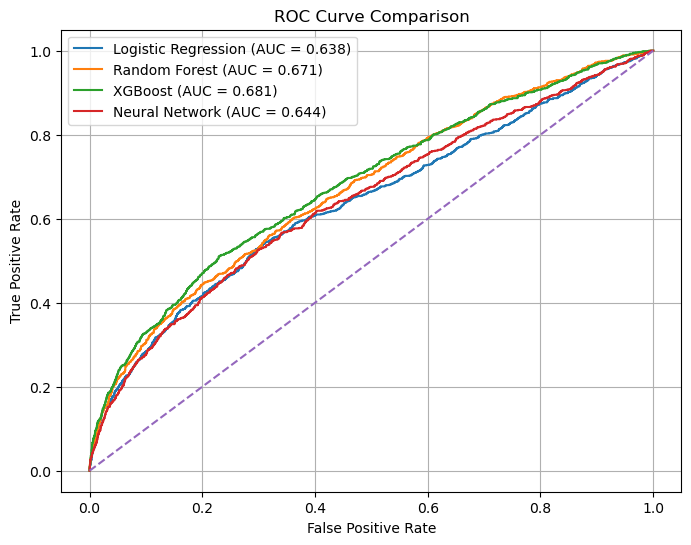

In [49]:
# =========================================
# ROC curve comparison
# =========================================

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logreg,
    tpr_logreg,
    label=f"Logistic Regression (AUC = {metrics_logreg['ROC-AUC']:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {metrics_rf['ROC-AUC']:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {metrics_xgb['ROC-AUC']:.3f})"
)

plt.plot(
    fpr_nn,
    tpr_nn,
    label=f"Neural Network (AUC = {metrics_nn['ROC-AUC']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.savefig("assets/roc_curve_4models.png", bbox_inches="tight", dpi=150)

plt.show()

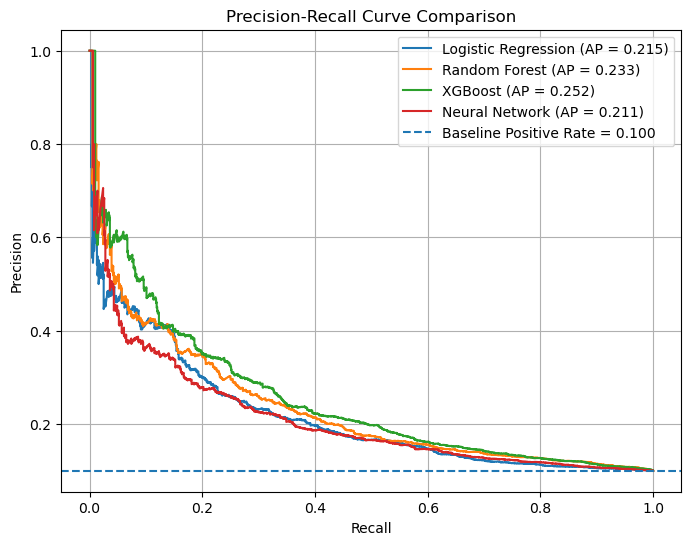

In [50]:
# =========================================
# Precision-Recall curve comparison
# =========================================

precision_lr_curve, recall_lr_curve, _ = precision_recall_curve(y_test, y_proba_logreg)

precision_rf_curve, recall_rf_curve, _ = precision_recall_curve(y_test, y_proba_rf)

precision_xgb_curve, recall_xgb_curve, _ = precision_recall_curve(y_test, y_proba_xgb)

precision_nn_curve, recall_nn_curve, _ = precision_recall_curve(y_test, y_proba_nn)

baseline_rate = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    recall_lr_curve,
    precision_lr_curve,
    label=f"Logistic Regression (AP = {metrics_logreg['Average Precision']:.3f})"
)

plt.plot(
    recall_rf_curve,
    precision_rf_curve,
    label=f"Random Forest (AP = {metrics_rf['Average Precision']:.3f})"
)

plt.plot(
    recall_xgb_curve,
    precision_xgb_curve,
    label=f"XGBoost (AP = {metrics_xgb['Average Precision']:.3f})"
)

plt.plot(
    recall_nn_curve,
    precision_nn_curve,
    label=f"Neural Network (AP = {metrics_nn['Average Precision']:.3f})"
)

plt.axhline(
    baseline_rate,
    linestyle="--",
    label=f"Baseline Positive Rate = {baseline_rate:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")

plt.legend()
plt.grid(True)
plt.savefig("assets/pr_curve_4models.png", bbox_inches="tight", dpi=150)

plt.show()

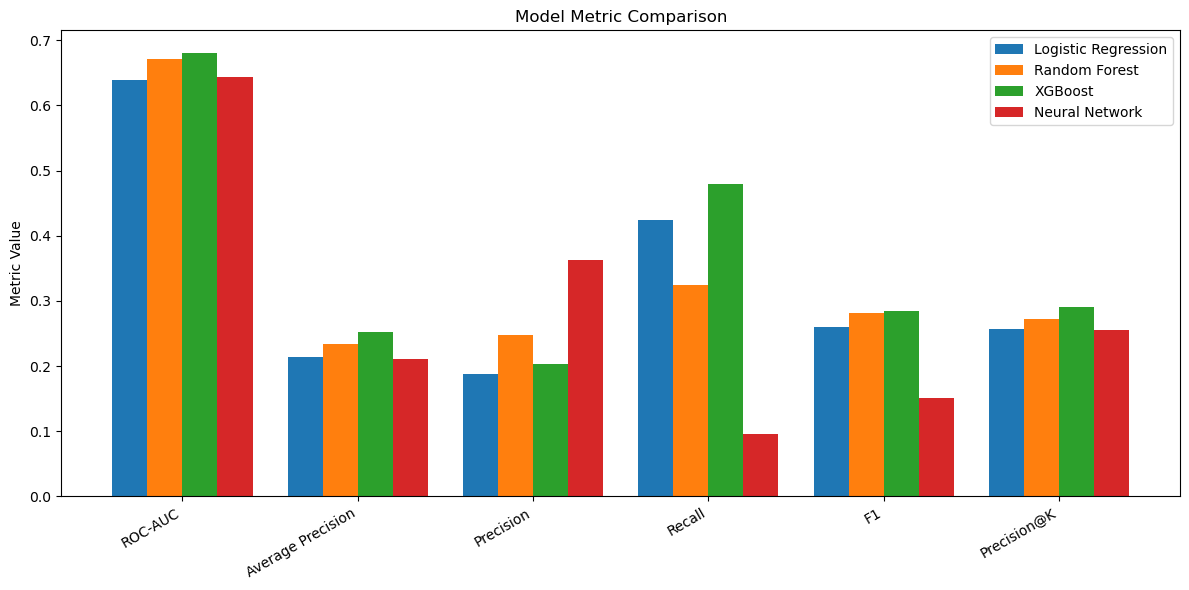

In [51]:
# =========================================
# Metric bar chart comparison
# =========================================

plot_metrics = [
    "ROC-AUC",
    "Average Precision",
    "Precision",
    "Recall",
    "F1",
    "Precision@K"
]

plot_df = comparison_df[
    comparison_df["metric"].isin(plot_metrics)
].copy()

x = np.arange(len(plot_df))
width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(
    x - 1.5 * width,
    plot_df["Logistic Regression"],
    width,
    label="Logistic Regression"
)

plt.bar(
    x - 0.5 * width,
    plot_df["Random Forest"],
    width,
    label="Random Forest"
)

plt.bar(
    x + 0.5 * width,
    plot_df["XGBoost"],
    width,
    label="XGBoost"
)

plt.bar(
    x + 1.5 * width,
    plot_df["Neural Network"],
    width,
    label="Neural Network"
)

plt.xticks(
    x,
    plot_df["metric"],
    rotation=30,
    ha="right"
)

plt.ylabel("Metric Value")

plt.title("Model Metric Comparison")

plt.legend()

plt.tight_layout()
plt.savefig("assets/metric_comparison_4models.png", bbox_inches="tight", dpi=150)

plt.show()

In [23]:
# ==========================================
# Cell 15 — Confusion matrices
# ==========================================
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

cm_logreg_df = pd.DataFrame(
    cm_logreg,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_xgb_df = pd.DataFrame(
    cm_xgb,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Logistic Regression Confusion Matrix")
display(cm_logreg_df)

Logistic Regression Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,7163,1837
Actual 1,576,424


In [24]:
print("XGBoost Confusion Matrix")
display(cm_xgb_df)

XGBoost Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,7113,1887
Actual 1,520,480


In [25]:
from sklearn.metrics import confusion_matrix

models_preds = {
    "Logistic Regression": y_pred_logreg,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "Neural Network": y_pred_nn
}

for model_name, y_pred in models_preds.items():
    cm = confusion_matrix(y_test, y_pred)

    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )

    print(f"{model_name} Confusion Matrix")
    display(cm_df)

Logistic Regression Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,7163,1837
Actual 1,576,424


Random Forest Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,8016,984
Actual 1,675,325


XGBoost Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,7113,1887
Actual 1,520,480


Neural Network Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,8833,167
Actual 1,905,95


In [26]:
# ==========================================
# Cell 16 — Logistic regression coefficients
# ==========================================
logreg_feature_names = logreg_pipeline.named_steps["preprocess"].get_feature_names_out()
logreg_coefs = logreg_pipeline.named_steps["model"].coef_[0]

logreg_coef_df = pd.DataFrame({
    "feature": logreg_feature_names,
    "coefficient": logreg_coefs,
    "abs_coefficient": np.abs(logreg_coefs),
}).sort_values("abs_coefficient", ascending=False)

print("Top positive/negative logistic regression coefficients")
display(logreg_coef_df.head(20))

Top positive/negative logistic regression coefficients


,feature,coefficient,abs_coefficient
8,num__sum_vote_4w,0.484358,0.484358
4,num__max_rating_4w,-0.409305,0.409305
1,num__mean_rating_4w,0.354456,0.354456
7,num__mean_vote_4w,0.260252,0.260252
16,num__vote_per_review_4w,0.260252,0.260252
18,cat__category_Electronics,-0.188506,0.188506
9,num__mean_review_text_len_4w,-0.159299,0.159299
5,num__median_rating_4w,0.131229,0.131229
2,num__std_rating_4w,0.106125,0.106125
3,num__min_rating_4w,-0.092449,0.092449


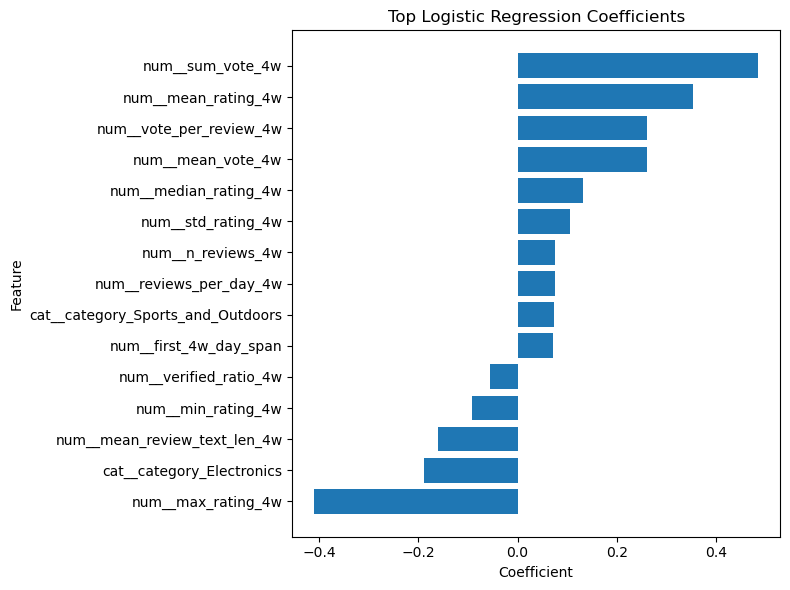

In [27]:
# ==========================================
# Cell 17 — Plot top logistic regression coefficients
# ==========================================
top_n = 15
top_coef_df = logreg_coef_df.head(top_n).sort_values("coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top_coef_df["feature"], top_coef_df["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

In [28]:
# ==========================================
# Cell 18 — XGBoost feature importances
# ==========================================
xgb_feature_names = xgb_preprocess.get_feature_names_out()
xgb_importances = xgb_model.feature_importances_

xgb_importance_df = pd.DataFrame({
    "feature": xgb_feature_names,
    "importance": xgb_importances,
}).sort_values("importance", ascending=False)

display(xgb_importance_df.head(20))

,feature,importance
8,num__sum_vote_4w,0.152737
16,num__vote_per_review_4w,0.065703
0,num__n_reviews_4w,0.062591
9,num__mean_review_text_len_4w,0.054355
7,num__mean_vote_4w,0.049345
11,num__first_4w_day_span,0.047169
6,num__verified_ratio_4w,0.046500
15,num__reviews_per_day_4w,0.044174
18,cat__category_Electronics,0.043756
10,num__mean_summary_len_4w,0.037770


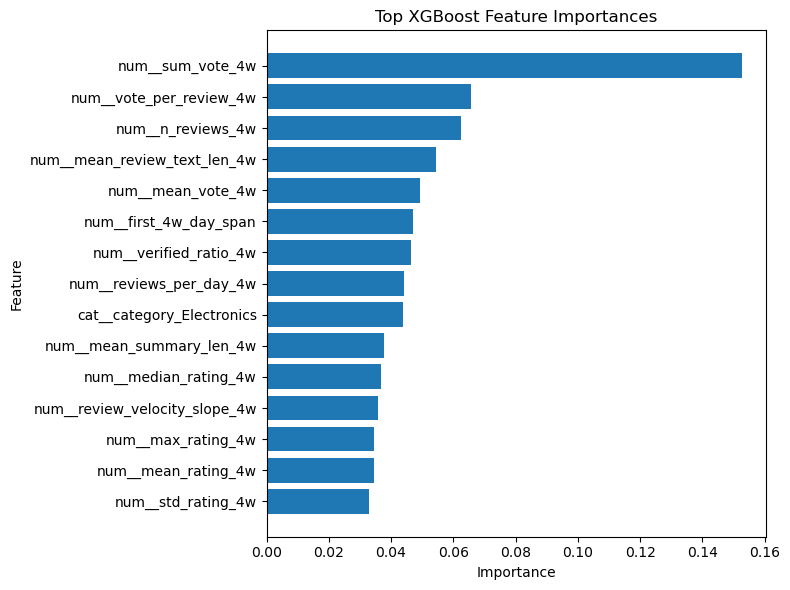

In [29]:
# ==========================================
# Cell 19 — Plot top XGBoost feature importances
# ==========================================
top_n = 15
top_importance_df = xgb_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_importance_df["feature"], top_importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top XGBoost Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
# Random Forest feature importances

rf_feature_names = xgb_preprocess.get_feature_names_out()
rf_importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances,
}).sort_values("importance", ascending=False)

print("Top Random Forest feature importances")
display(rf_importance_df.head(20))

Top Random Forest feature importances


,feature,importance
9,num__mean_review_text_len_4w,0.166372
8,num__sum_vote_4w,0.149596
7,num__mean_vote_4w,0.106433
16,num__vote_per_review_4w,0.100252
10,num__mean_summary_len_4w,0.100192
13,num__review_velocity_slope_4w,0.042560
12,num__rating_slope_4w,0.039316
11,num__first_4w_day_span,0.037039
6,num__verified_ratio_4w,0.033165
15,num__reviews_per_day_4w,0.032442


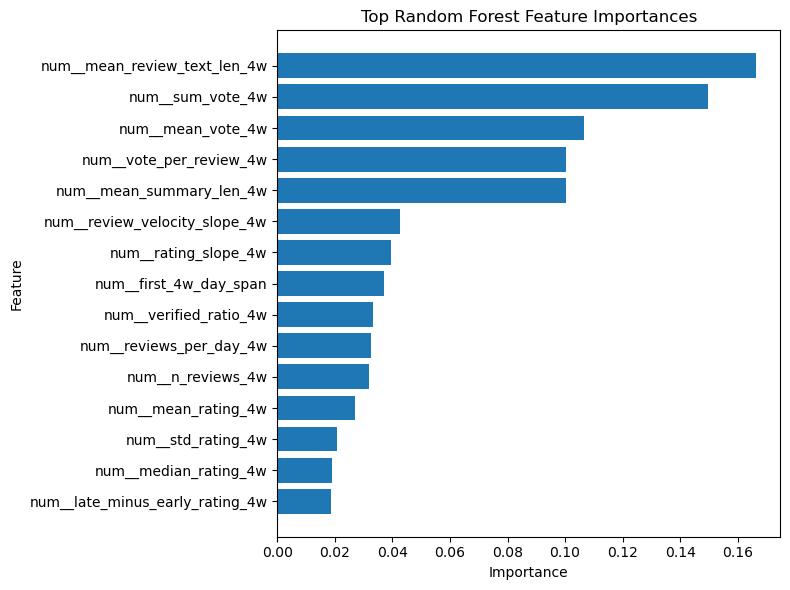

In [ ]:
# =========================================
# Plot top Random Forest feature importances
# =========================================

top_n = 15
top_rf_importance_df = rf_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_rf_importance_df["feature"], top_rf_importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [32]:
# =========================================
# Cell 20 — Category-level performance for all models
# =========================================

def make_test_results(y_proba, y_pred):
    df_result = X_test.copy()
    df_result["asin"] = asin_test.values
    df_result["y_true"] = y_test.values
    df_result["y_proba"] = y_proba
    df_result["y_pred"] = y_pred
    return df_result

test_results_logreg = make_test_results(y_proba_logreg, y_pred_logreg)
test_results_rf = make_test_results(y_proba_rf, y_pred_rf)
test_results_xgb = make_test_results(y_proba_xgb, y_pred_xgb)
test_results_nn = make_test_results(y_proba_nn, y_pred_nn)

category_metrics_logreg = compute_category_metrics(test_results_logreg)
category_metrics_rf = compute_category_metrics(test_results_rf)
category_metrics_xgb = compute_category_metrics(test_results_xgb)
category_metrics_nn = compute_category_metrics(test_results_nn)

print("Category-level metrics — Logistic Regression")
display(category_metrics_logreg)

print("Category-level metrics — Random Forest")
display(category_metrics_rf)

print("Category-level metrics — XGBoost")
display(category_metrics_xgb)

print("Category-level metrics — Neural Network")
display(category_metrics_nn)

Category-level metrics — Logistic Regression


,category,n_products,positive_rate,roc_auc,avg_precision,precision,recall,f1
0,Tools and Home Improvement,1971,0.097920,0.656096,0.228969,0.209790,0.466321,0.289389
1,Electronics,2024,0.101285,0.651604,0.227369,0.198529,0.395122,0.264274
2,"Clothing, Shoes and Jewelry",2013,0.104322,0.647152,0.271963,0.202151,0.447619,0.278519
3,Sports_and_Outdoors,2051,0.095076,0.643756,0.203557,0.165692,0.435897,0.240113
4,Toys_and_Games,1941,0.101494,0.621030,0.208542,0.165919,0.375635,0.230171


Category-level metrics — Random Forest


,category,n_products,positive_rate,roc_auc,avg_precision,precision,recall,f1
0,Tools and Home Improvement,1971,0.097920,0.709894,0.238672,0.243728,0.352332,0.288136
1,Toys_and_Games,1941,0.101494,0.709365,0.263285,0.262963,0.360406,0.304069
2,Electronics,2024,0.101285,0.658416,0.246644,0.280335,0.326829,0.301802
3,Sports_and_Outdoors,2051,0.095076,0.644285,0.186277,0.196203,0.317949,0.242661
4,"Clothing, Shoes and Jewelry",2013,0.104322,0.635886,0.259707,0.278049,0.271429,0.274699


Category-level metrics — XGBoost


,category,n_products,positive_rate,roc_auc,avg_precision,precision,recall,f1
0,Tools and Home Improvement,1971,0.097920,0.721530,0.253168,0.207921,0.544041,0.300860
1,Toys_and_Games,1941,0.101494,0.717001,0.276668,0.223158,0.538071,0.315476
2,Sports_and_Outdoors,2051,0.095076,0.669725,0.212903,0.173333,0.466667,0.252778
3,Electronics,2024,0.101285,0.667754,0.256482,0.207763,0.443902,0.283048
4,"Clothing, Shoes and Jewelry",2013,0.104322,0.636596,0.281572,0.205189,0.414286,0.274448


Category-level metrics — Neural Network


,category,n_products,positive_rate,roc_auc,avg_precision,precision,recall,f1
0,Toys_and_Games,1941,0.101494,0.676504,0.241738,0.451613,0.071066,0.122807
1,Tools and Home Improvement,1971,0.097920,0.658302,0.191144,0.250000,0.098446,0.141264
2,"Clothing, Shoes and Jewelry",2013,0.104322,0.654668,0.239441,0.500000,0.104762,0.173228
3,Electronics,2024,0.101285,0.621810,0.237177,0.392857,0.107317,0.168582
4,Sports_and_Outdoors,2051,0.095076,0.621740,0.182625,0.327273,0.092308,0.144000


In [46]:
# =========================================
# Cell 21 — Category-level ROC-AUC comparison
# =========================================

category_auc_compare = (
    category_metrics_logreg[["category", "roc_auc"]]
    .merge(category_metrics_rf[["category", "roc_auc"]], on="category", suffixes=("_logreg", "_rf"))
    .merge(category_metrics_xgb[["category", "roc_auc"]], on="category")
    .rename(columns={"roc_auc": "roc_auc_xgb"})
    .merge(category_metrics_nn[["category", "roc_auc"]], on="category")
    .rename(columns={"roc_auc": "roc_auc_nn"})
)

category_auc_compare = category_auc_compare.sort_values(
    "roc_auc_xgb",
    ascending=False
).reset_index(drop=True)

display(category_auc_compare)

,category,roc_auc_logreg,roc_auc_rf,roc_auc_xgb,roc_auc_nn
0,Tools and Home Improvement,0.656096,0.709894,0.721530,0.658302
1,Toys_and_Games,0.621030,0.709365,0.717001,0.676504
2,Sports_and_Outdoors,0.643756,0.644285,0.669725,0.621740
3,Electronics,0.651604,0.658416,0.667754,0.621810
4,"Clothing, Shoes and Jewelry",0.647152,0.635886,0.636596,0.654668


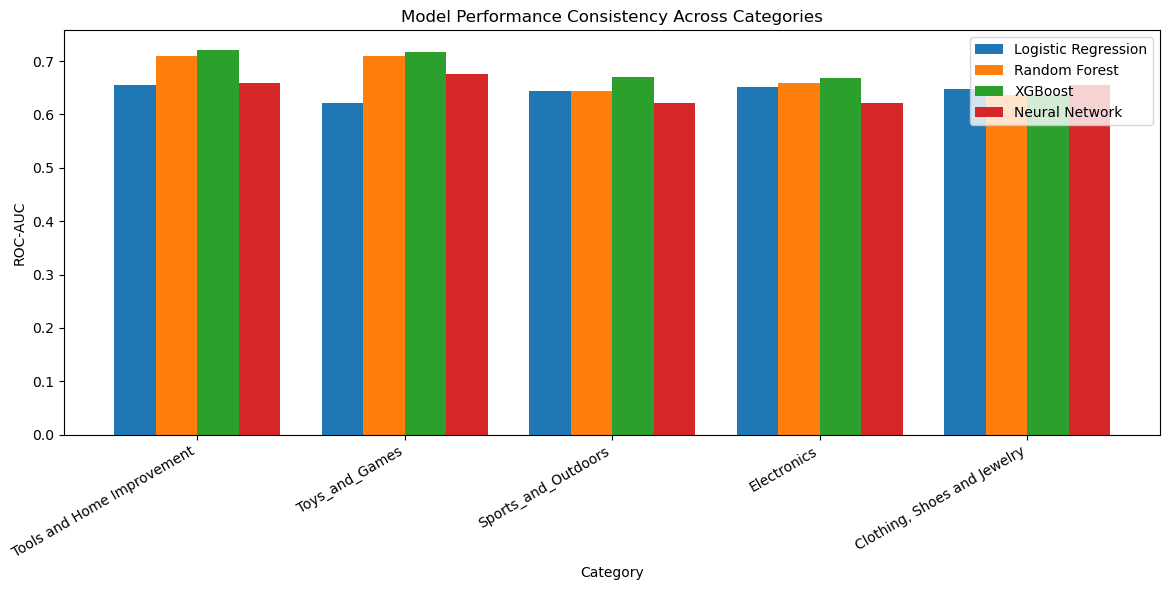

In [34]:
# =========================================
# Cell 22 — Plot category ROC-AUC for all models
# =========================================

x = np.arange(len(category_auc_compare))
width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(
    x - 1.5 * width,
    category_auc_compare["roc_auc_logreg"],
    width,
    label="Logistic Regression"
)

plt.bar(
    x - 0.5 * width,
    category_auc_compare["roc_auc_rf"],
    width,
    label="Random Forest"
)

plt.bar(
    x + 0.5 * width,
    category_auc_compare["roc_auc_xgb"],
    width,
    label="XGBoost"
)

plt.bar(
    x + 1.5 * width,
    category_auc_compare["roc_auc_nn"],
    width,
    label="Neural Network"
)

plt.xticks(
    x,
    category_auc_compare["category"],
    rotation=30,
    ha="right"
)

plt.ylabel("ROC-AUC")
plt.xlabel("Category")
plt.title("Model Performance Consistency Across Categories")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# ==========================================
# Cell 23 — Final summary table for report use
# =========================================

report_metrics = [
    "ROC-AUC",
    "Average Precision",
    "Precision",
    "Recall",
    "F1",
    "Precision@K"
]

report_table = comparison_df[
    comparison_df["metric"].isin(report_metrics)
].copy()

display(report_table)

,metric,Logistic Regression,Random Forest,XGBoost,Neural Network,XGB_minus_LogReg
0,ROC-AUC,0.638440,0.670620,0.681057,0.643884,0.042617
1,Average Precision,0.214516,0.233253,0.251563,0.210842,0.037047
2,Precision,0.187528,0.248281,0.202788,0.362595,0.015261
3,Recall,0.424000,0.325000,0.480000,0.095000,0.056000
4,F1,0.260043,0.281507,0.285120,0.150555,0.025077
5,Precision@K,0.257000,0.272000,0.290000,0.255000,0.033000


## Improved Definition of Product Success

Our original success label used lifetime review count because review volume reflects product traction and customer engagement. However, review count alone does not always mean a product is truly successful.

For example, a product with millions of reviews but mostly 1-star ratings should not be considered a good product. This shows that popularity and quality are different.

A better future success definition should combine both engagement and quality:

- Engagement: review count, review velocity, helpful votes
- Quality: average rating, rating stability, sentiment

A possible improved score could be:

success_score = normalized_review_count × average_rating

or

success_score = 0.7 × normalized_review_count + 0.3 × normalized_average_rating

This would prevent highly reviewed but poorly rated products from being incorrectly labeled as successful.

## Summary

Using only the first 4 weeks of post-launch review data, both models achieved better-than-random performance in
predicting which products would eventually fall into the top 10% of their category.

XGBoost outperformed Logistic Regression across all major metrics, indicating that nonlinear relationships and feature
interactions improve early product success prediction. The strongest gains appeared in ROC-AUC, recall, and Precision@K,
suggesting that XGBoost is especially better at identifying and ranking promising products early.

These results support the conclusion that early product success is partially predictable, though performance remains
moderate and likely limited by the current feature set. The next major improvement is to add NLP-derived features such
as sentiment and review text signals.

In [40]:
# ==========================================
# Q2 — Correlation of early indicators with success
# ==========================================
corr_df = product_df[feature_cols_num + [target_col]].corr(numeric_only=True)

target_corr_df = (
    corr_df[[target_col]]
    .drop(index=target_col)
    .rename(columns={target_col: "correlation_with_success"})
    .sort_values("correlation_with_success", ascending=False)
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(target_corr_df)

,feature,correlation_with_success
0,sum_vote_4w,0.149646
1,mean_vote_4w,0.128280
2,vote_per_review_4w,0.128280
3,n_reviews_4w,0.088263
4,reviews_per_day_4w,0.088263
5,review_velocity_slope_4w,0.060348
6,first_4w_day_span,0.053461
7,mean_review_text_len_4w,0.040094
8,std_rating_4w,0.027445
9,max_rating_4w,0.011351


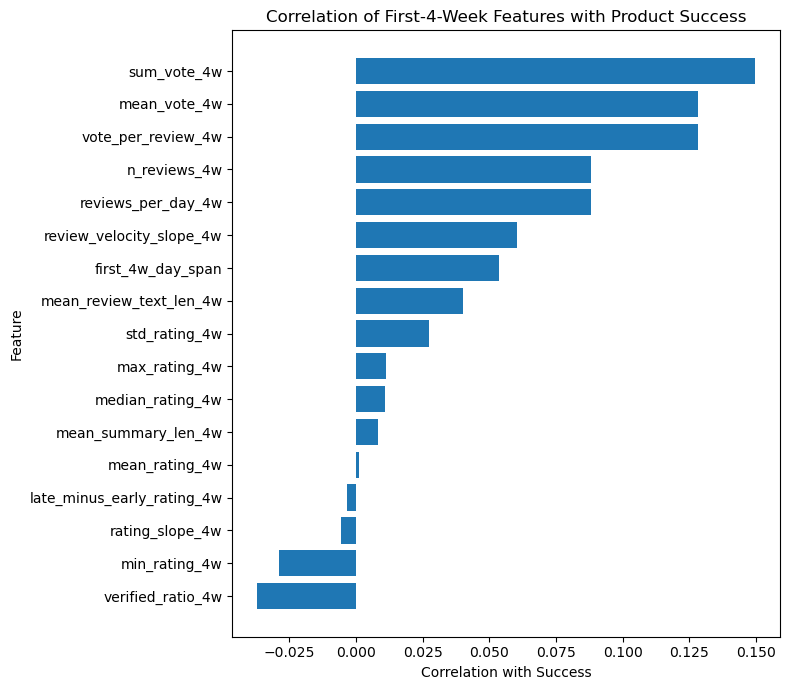

In [41]:
# ==========================================
# Q2 — Plot feature correlations with success
# ==========================================
plot_corr_df = target_corr_df.sort_values("correlation_with_success")

plt.figure(figsize=(8, 7))
plt.barh(plot_corr_df["feature"], plot_corr_df["correlation_with_success"])
plt.xlabel("Correlation with Success")
plt.ylabel("Feature")
plt.title("Correlation of First-4-Week Features with Product Success")
plt.tight_layout()
plt.show()

In [42]:
# ==========================================
# Q3 — Merge category ROC-AUC by model
# ==========================================
category_auc_compare = category_metrics_logreg[["category", "roc_auc"]].merge(
    category_metrics_xgb[["category", "roc_auc"]],
    on="category",
    suffixes=("_logreg", "_xgb")
)

category_auc_compare = category_auc_compare.sort_values("roc_auc_xgb", ascending=False).reset_index(drop=True)

display(category_auc_compare)

,category,roc_auc_logreg,roc_auc_xgb
0,Tools and Home Improvement,0.656096,0.721530
1,Toys_and_Games,0.621030,0.717001
2,Sports_and_Outdoors,0.643756,0.669725
3,Electronics,0.651604,0.667754
4,"Clothing, Shoes and Jewelry",0.647152,0.636596


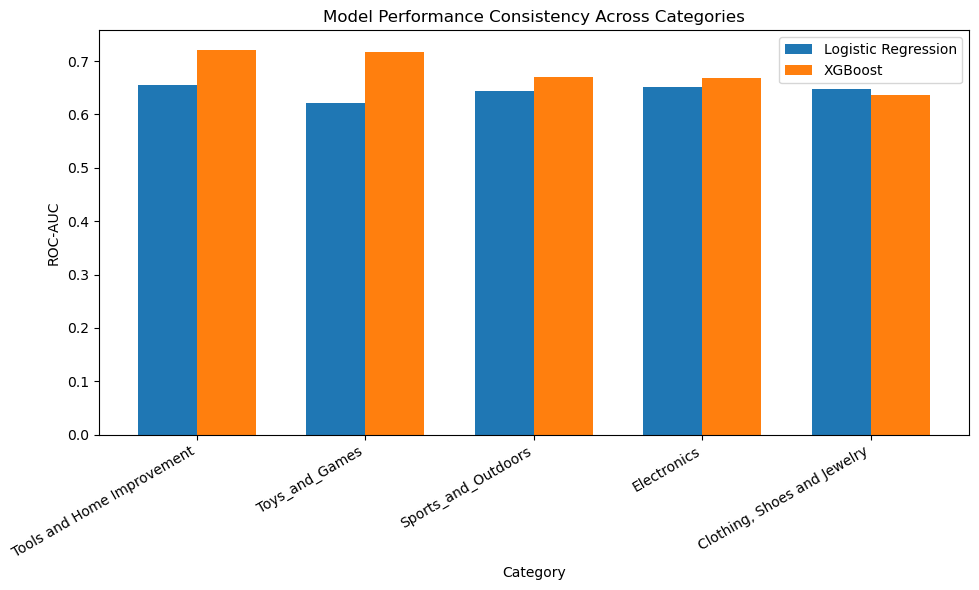

In [43]:
# ==========================================
# Q3 — ROC-AUC by category for both models
# ==========================================
x = np.arange(len(category_auc_compare))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, category_auc_compare["roc_auc_logreg"], width, label="Logistic Regression")
plt.bar(x + width / 2, category_auc_compare["roc_auc_xgb"], width, label="XGBoost")

plt.xticks(x, category_auc_compare["category"], rotation=30, ha="right")
plt.ylabel("ROC-AUC")
plt.xlabel("Category")
plt.title("Model Performance Consistency Across Categories")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# ==========================================
# Q3 — Summary stats for consistency across categories
# ==========================================

consistency_summary = pd.DataFrame({
    "statistic": ["mean", "std", "min", "max", "range"],

    "Logistic Regression": [
        category_auc_compare["roc_auc_logreg"].mean(),
        category_auc_compare["roc_auc_logreg"].std(),
        category_auc_compare["roc_auc_logreg"].min(),
        category_auc_compare["roc_auc_logreg"].max(),
        category_auc_compare["roc_auc_logreg"].max() - category_auc_compare["roc_auc_logreg"].min(),
    ],

    "Random Forest": [
        category_auc_compare["roc_auc_rf"].mean(),
        category_auc_compare["roc_auc_rf"].std(),
        category_auc_compare["roc_auc_rf"].min(),
        category_auc_compare["roc_auc_rf"].max(),
        category_auc_compare["roc_auc_rf"].max() - category_auc_compare["roc_auc_rf"].min(),
    ],

    "XGBoost": [
        category_auc_compare["roc_auc_xgb"].mean(),
        category_auc_compare["roc_auc_xgb"].std(),
        category_auc_compare["roc_auc_xgb"].min(),
        category_auc_compare["roc_auc_xgb"].max(),
        category_auc_compare["roc_auc_xgb"].max() - category_auc_compare["roc_auc_xgb"].min(),
    ],

    "Neural Network": [
        category_auc_compare["roc_auc_nn"].mean(),
        category_auc_compare["roc_auc_nn"].std(),
        category_auc_compare["roc_auc_nn"].min(),
        category_auc_compare["roc_auc_nn"].max(),
        category_auc_compare["roc_auc_nn"].max() - category_auc_compare["roc_auc_nn"].min(),
    ],
})

display(consistency_summary)

,statistic,Logistic Regression,Random Forest,XGBoost,Neural Network
0,mean,0.643927,0.671569,0.682521,0.646605
1,std,0.013617,0.035665,0.036061,0.024129
2,min,0.621030,0.635886,0.636596,0.621740
3,max,0.656096,0.709894,0.721530,0.676504
4,range,0.035066,0.074008,0.084934,0.054764


In [48]:
# ==========================================
# Q3 — Best and worst category by model
# ==========================================

model_columns = {
    "Logistic Regression": "roc_auc_logreg",
    "Random Forest": "roc_auc_rf",
    "XGBoost": "roc_auc_xgb",
    "Neural Network": "roc_auc_nn"
}

summary_rows = []

for model_name, col in model_columns.items():
    best_row = category_auc_compare.loc[category_auc_compare[col].idxmax()]
    worst_row = category_auc_compare.loc[category_auc_compare[col].idxmin()]

    summary_rows.append({
        "model": model_name,
        "best_category": best_row["category"],
        "best_auc": best_row[col],
        "worst_category": worst_row["category"],
        "worst_auc": worst_row[col],
    })

best_worst_df = pd.DataFrame(summary_rows)

display(best_worst_df)

,model,best_category,best_auc,worst_category,worst_auc
0,Logistic Regression,Tools and Home Improvement,0.656096,Toys_and_Games,0.621030
1,Random Forest,Tools and Home Improvement,0.709894,"Clothing, Shoes and Jewelry",0.635886
2,XGBoost,Tools and Home Improvement,0.721530,"Clothing, Shoes and Jewelry",0.636596
3,Neural Network,Toys_and_Games,0.676504,Sports_and_Outdoors,0.621740


## Final Model Comparison Summary

After instructor feedback, we expanded the model comparison beyond Logistic Regression and XGBoost by adding Random Forest and a Neural Network model.

Logistic Regression is used as the simple baseline model because it is easy to interpret. Random Forest provides another ensemble-based model that can capture nonlinear patterns. XGBoost is a stronger gradient boosting model that handles feature interactions well. The Neural Network tests whether a more complex nonlinear model improves prediction performance.

Overall, the expanded comparison gives a stronger evaluation because it compares a linear baseline, two tree-based ensemble methods, and a neural network model.